# Condition-Based RADAR–LiDAR Velocity Analysis

## SETUP

In [1]:
import pandas as pd
import numpy as np
from truckscenes import TruckScenes
import matplotlib.pyplot as plt
import re

from src.config import DATA_ROOT, METADATA_ROOT, SENSOR_ROOT
from src.condition.condition_config import CONDITIONS
from src.condition.condition_data import (
    build_condition_table,
    build_condition_inventory,
    create_distance_bands,
)
from src.sensor_observation import build_sensor_data_df
from src.annotation_velocity import build_vehicle_reference_df
from src.radar_velocity import (
    build_target_radar_points_df,
    build_radar_radial_df,
    build_radar_velocity_df,
)
from src.lidar_velocity import (
    build_target_lidar_information_df,
    build_lidar_target_states_df,
    build_lidar_velocity_df,
)
from src.comparison import build_velocity_comparison_df
from src.condition.condition_velocity import (
    add_velocity_analysis_columns,
    availability_summary,
    error_summary,
)
from src.condition.cross_condition import (
    build_cross_condition_df,
    build_paired_long_df,
    prepare_interaction_model_df,
    fit_sensor_condition_model,
    fit_condition_interaction_model,
)
from src.condition.cross_condition_visualisation import (
    plot_sensor_interaction_coefficients,
    plot_sensor_distance_interaction,
    plot_sensor_condition_grid,
    plot_condition_interactions,
)
from src.condition.sensor_fusion import (
    add_fusion_columns,
    complementarity_summary,
    fusion_accuracy_summary,
    fusion_condition_summary,
    fusion_gain_summary,
)
from src.condition.sensor_fusion_visualisation import (
    plot_fusion_complementarity,
    plot_overall_fusion_accuracy,
    plot_fusion_condition_grid,
    plot_fusion_distance,
    plot_fusion_gain_grid,
    plot_fusion_gain_distance,
)
from src.dataset_filtering import prepare_available_sample_data

## 1. Objective and Scope

## 2. Analysis Setup

### Build Sensor Observation Data

In [2]:
trucksc = TruckScenes(dataroot=DATA_ROOT)
sensor_data_df = build_sensor_data_df(metadata_root=METADATA_ROOT)
keyframe_df = sensor_data_df[sensor_data_df["Is Key Frame"].eq(True)].copy()
radar_observation_df = keyframe_df[keyframe_df["Modality"].eq("RADAR")].reset_index(drop=True)
lidar_observation_df = keyframe_df[keyframe_df["Modality"].eq("LiDAR")].reset_index(drop=True)

Auto-detected latest version: v1.2-mini
Loading truckscenes tables for version v1.2-mini...
11 attribute,
18 calibrated_sensor,
27 category,
20090 ego_motion_cabin,
20089 ego_motion_chassis,
20116 ego_pose,
1094 instance,
400 sample,
25750 sample_annotation,
43556 sample_data,
10 scene,
18 sensor,
4 visibility,
10 weather_annotation,
Done loading in 0.777 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


f:\CITS3200\Boeing-RADAR-Autonomous-\.venv311\Lib\site-packages\truckscenes\truckscenes.py:100: UserWarning: The visualization dependencies are not installed on your system! Run 'pip install "truckscenes-devkit[all]"'.
  warnings.warn('''The visualization dependencies are not installed on your system! '''


In [ ]:
available_sample_data, summary, extra_files = (prepare_available_sample_data())
display(summary)

sensor_data_df = build_sensor_data_df(
    metadata_root=METADATA_ROOT,
    sample_data_df=available_sample_data,
)

keyframe_df = sensor_data_df[sensor_data_df["Is Key Frame"].eq(True)].copy()
radar_observation_df = (keyframe_df[keyframe_df["Modality"].eq("RADAR")].reset_index(drop=True))
lidar_observation_df = (keyframe_df[keyframe_df["Modality"].eq("LiDAR")].reset_index(drop=True))

Metadata records                    43556
Available local files               43556
Unavailable locally                     0
Extra / unreferenced local files        0
Name: Dataset Filtering Summary, dtype: int64

In [4]:
# if extra_files:
#     print("First extra files:")
#     print(*list(extra_files)[:20], sep="\n")

### Build Reference Velocity

In [5]:
vehicle_reference_df = build_vehicle_reference_df(
    trucksc.sample,
    trucksc.sample_annotation,
    trucksc.instance,
    trucksc.category,
)

print("Reference intervals:", len(vehicle_reference_df))

Reference intervals: 15743


### Bulid RADAR Velocity

The RADAR velocity analysis reconstructs target motion from point-level radial-velocity information.

Each RADAR return contributes a radial-velocity constraint along its own line-of-sight (LOS) direction. After ego-motion compensation and coordinate transformation, multiple RADAR constraints are combined to estimate the target's 2D ground-plane velocity.

The reconstruction is performed for each annotation-derived velocity interval using RADAR observations associated with both the start and end annotations. This keeps the RADAR estimate aligned with the same temporal interval used for the annotation-derived reference velocity and provides multiple LOS constraints for the 2D reconstruction.

A RADAR velocity is considered **reconstructable** only when:

1. RADAR constraints are available at both interval endpoints; and
2. the combined 2D constraint matrix has rank 2.

A rank-2 system is required because the target velocity contains two unknown ground-plane components, `vx` and `vy`. Multiple sufficiently independent LOS directions are therefore needed to reconstruct the full 2D velocity. The current implementation explicitly combines the start- and end-point constraints and rejects systems with rank below 2. 

After a full-rank solution is obtained, its numerical stability is assessed using the condition number of the 2D constraint matrix. The project baseline uses:

`is_stable_2d = True` when `condition_2d <= 20`.

The threshold of 20 is not an official TruckScenes threshold. It is the existing project baseline established during the earlier RADAR velocity analysis.

A sensitivity check was performed using condition-number thresholds of 5, 10, 20, 30, 50 and 100. Median velocity error remained broadly similar around thresholds of 20–30, whereas looser thresholds increasingly admitted estimates with larger error spread. The existing threshold of 20 was therefore retained as a conservative and methodologically consistent baseline rather than re-tuning the threshold for the current analysis.

The RADAR results are therefore interpreted at two levels:

- **Reconstructable RADAR velocity:** a full-rank 2D velocity solution can be obtained.
- **Stable RADAR velocity:** the reconstructed solution also satisfies the numerical-stability criterion.

All full-rank RADAR estimates are retained when analysing reconstruction availability. Only numerically stable estimates are used for final RADAR velocity-accuracy and paired RADAR–LiDAR accuracy comparisons.

The stability criterion assesses numerical conditioning rather than prediction correctness. A stable solution is not guaranteed to be accurate, while an unstable solution is not necessarily incorrect; however, unstable systems are more sensitive to measurement noise and small changes in the RADAR constraints.

In [ ]:
radar_tokens = set(radar_observation_df["Token"])
radar_sample_tokens = set(radar_observation_df["Sample Token"])

radar_sample_data = available_sample_data[available_sample_data["token"].isin(radar_tokens)].copy()
radar_sample_data_lookup = radar_sample_data.set_index("token").to_dict("index")

ego_pose_tokens = set(radar_sample_data["ego_pose_token"].dropna())
radar_ego_pose_lookup = {
    x["token"]: x
    for x in trucksc.ego_pose
    if x["token"] in ego_pose_tokens
}

calibrated_sensor_tokens = set(radar_sample_data["calibrated_sensor_token"].dropna())
radar_calibrated_sensor_lookup = {
    x["token"]: x
    for x in trucksc.calibrated_sensor
    if x["token"] in calibrated_sensor_tokens
}

radar_annotations = [
    x
    for x in trucksc.sample_annotation
    if x["sample_token"] in radar_sample_tokens
]

In [7]:
target_radar_points_df = build_target_radar_points_df(
    radar_observation_df,
    radar_annotations,
    trucksc.instance,
    trucksc.category,
    radar_sample_data_lookup,
    radar_ego_pose_lookup,
    radar_calibrated_sensor_lookup,
    SENSOR_ROOT,
)

radar_radial_df = build_radar_radial_df(
    target_radar_points_df,
    radar_sample_data_lookup,
    radar_ego_pose_lookup,
    radar_calibrated_sensor_lookup,
    trucksc.ego_motion_cabin,
)

radar_velocity_df = build_radar_velocity_df(
    radar_radial_df,
    vehicle_reference_df,
)

In [8]:
print("Reference intervals:", len(vehicle_reference_df))
print("RADAR reconstructable intervals:", len(radar_velocity_df))
print("RADAR stable intervals:", radar_velocity_df["is_stable_2d"].sum())

Reference intervals: 15743
RADAR reconstructable intervals: 7706
RADAR stable intervals: 3016


### Bulid LiDAR Velocity

In [ ]:
lidar_tokens = set(lidar_observation_df["Token"])
lidar_sample_tokens = set(lidar_observation_df["Sample Token"])

lidar_sample_data = available_sample_data[available_sample_data["token"].isin(lidar_tokens)].copy()
lidar_sample_data_lookup = lidar_sample_data.set_index("token").to_dict("index")

ego_pose_tokens = set(lidar_sample_data["ego_pose_token"].dropna())
lidar_ego_pose_lookup = {
    x["token"]: x
    for x in trucksc.ego_pose
    if x["token"] in ego_pose_tokens
}

calibrated_sensor_tokens = set(lidar_sample_data["calibrated_sensor_token"].dropna())
lidar_calibrated_sensor_lookup = {
    x["token"]: x
    for x in trucksc.calibrated_sensor
    if x["token"] in calibrated_sensor_tokens
}

lidar_annotations = [
    x
    for x in trucksc.sample_annotation
    if x["sample_token"] in lidar_sample_tokens
]

In [7]:
target_lidar_df = build_target_lidar_information_df(
    lidar_annotations,
    trucksc.instance,
    trucksc.category,
)

lidar_target_states_df = build_lidar_target_states_df(
    target_lidar_df,
    lidar_annotations,
    lidar_observation_df,
    lidar_sample_data_lookup,
    lidar_ego_pose_lookup,
    lidar_calibrated_sensor_lookup,
    SENSOR_ROOT,
)

lidar_velocity_df = build_lidar_velocity_df(
    lidar_target_states_df,
    lidar_annotations,
)

print("LiDAR velocity intervals:", len(lidar_velocity_df))

LiDAR velocity intervals: 8007


### Build Comparison Data

In [ ]:
local_sample_tokens = set(keyframe_df[keyframe_df["Modality"].isin(["RADAR", "LiDAR"])]["Sample Token"])

local_vehicle_reference_df = vehicle_reference_df[
    vehicle_reference_df["start_sample_token"].isin(local_sample_tokens)
    & vehicle_reference_df["end_sample_token"].isin(local_sample_tokens)
].copy()

In [12]:
comparison_df = build_velocity_comparison_df(
    local_vehicle_reference_df,
    radar_velocity_df,
    lidar_velocity_df,
)

interval_key = ["start_annotation_token", "end_annotation_token"]

comparison_df = comparison_df.merge(
    radar_velocity_df[interval_key + ["is_stable_2d"]],
    on=interval_key,
    how="left",
)

comparison_df["radar_reconstructable_available"] = comparison_df["radar_velocity_available"]
comparison_df["radar_stable_available"] = comparison_df["is_stable_2d"].fillna(False)
comparison_df["radar_velocity_available"] = comparison_df["radar_stable_available"]

In [13]:
print("Reference intervals:", len(comparison_df))
print("RADAR reconstructable:", comparison_df["radar_reconstructable_available"].sum())
print("RADAR stable:", comparison_df["radar_stable_available"].sum())
print("LiDAR available:", comparison_df["lidar_velocity_available"].sum())

Reference intervals: 15743
RADAR reconstructable: 7706
RADAR stable: 3016
LiDAR available: 8007


### Bulid Condition Data

In [ ]:
local_sample_tokens = set(keyframe_df[keyframe_df["Modality"].isin(["RADAR", "LiDAR"])]["Sample Token"])

In [ ]:
condition_df = build_condition_table(trucksc, sample_tokens=local_sample_tokens)
condition_inventory = build_condition_inventory(condition_df, CONDITIONS)
condition_inventory

,condition,value,scenes,samples,objects,annotations
0,area,city,4,160,569,14663
1,area,highway,4,160,468,9165
2,area,terminal,2,80,57,1922
3,weather,clear,4,160,436,10464
4,weather,overcast,3,120,425,9109
5,weather,rain,2,80,142,3612
6,weather,snow,1,40,91,2565
7,visibility,1,10,400,798,8346
8,visibility,2,10,387,450,2176
9,visibility,3,10,376,445,2034


In [16]:
setup_summary = pd.DataFrame({
    "dataset": [
        "Reference intervals",
        "RADAR velocity intervals",
        "LiDAR velocity intervals",
        "Comparison intervals",
        "Condition annotations",
    ],
    "rows": [
        len(local_vehicle_reference_df),
        len(radar_velocity_df),
        len(lidar_velocity_df),
        len(comparison_df),
        len(condition_df),
    ],
})

setup_summary

,dataset,rows
0,Reference intervals,15743
1,RADAR velocity intervals,7706
2,LiDAR velocity intervals,8007
3,Comparison intervals,15743
4,Condition annotations,25750


## 3. Methodology

### Conditions

The analysis covers five conditions:

- Area
- Weather
- Visibility
- Object Type
- Distance

Area has already been analysed and is retained as the existing baseline. The remaining conditions use the same velocity-comparison framework.

For interval-level visibility analysis, the lower visibility level of the start and end annotations was used. This conservative definition reflects the least-visible endpoint of each velocity interval while retaining intervals whose visibility changes between consecutive annotations.

For interval-level distance analysis, the mean 3D ego-to-target distance across the start and end annotations was used. The existing 25 m distance-band definition was then applied to the interval distance.

### Velocity Metrics

For each condition group, the following metrics are considered:

**Velocity availability**
- Number of valid velocity intervals
- RADAR available count and rate
- LiDAR available count and rate
- Number of intervals where both sensors provide a velocity estimate

**Velocity accuracy**
- Absolute 2D speed error relative to the annotation-derived reference velocity
- Median absolute error
- Interquartile range (IQR)

**Paired RADAR–LiDAR comparison**
- Direct accuracy comparison is performed only on intervals where both RADAR and LiDAR provide valid velocity estimates.
- This avoids comparing the two sensors using different target populations.

**Direction accuracy**
- Direction error is calculated using the existing project method.
- Direction results are only used for sufficiently moving targets because direction is not meaningful for near-stationary objects.

### Condition Association

Scene-level conditions such as Area and Weather are associated with velocity intervals using the scene of the interval start sample, consistent with the existing Area analysis.

Object Type is already available in the interval-level velocity data.

Visibility and Distance are annotation-level conditions. Their interval association is checked against the start and end annotations before the final grouping rule is applied.

### Data Sufficiency

Sample size is checked before interpreting each condition group. The analysis reports:

- valid velocity intervals
- RADAR available intervals
- LiDAR available intervals
- paired intervals

For scene-level conditions such as Area and Weather, the number of independent scenes is also reported.

Groups with very small sample sizes or limited scene coverage are retained where useful but are interpreted cautiously.

### Analysis Workflow

The overall analysis workflow is shown below.

![Analysis Workflow](results/condition/analysis_workflow.png)

## 4. Area

In [17]:
area_lookup = condition_df[
    ["annotation_token", "scene_token", "area"]
].rename(columns={
    "annotation_token": "start_annotation_token"
})

area_df = comparison_df.merge(
    area_lookup,
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

if area_df["area"].isna().any():
    raise ValueError(
        "Some velocity intervals could not be matched to an area."
    )

area_df = add_velocity_analysis_columns(area_df)

In [18]:
area_summary = availability_summary(area_df, "area")
area_summary

,area,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,city,4,374,8029,3707,1218,3826,1163,46.170133,15.170009,32.856757,47.652261,14.484992
1,highway,4,334,6276,2785,961,2867,926,44.375398,15.312301,34.506284,45.681963,14.754621
2,terminal,2,42,1438,1214,837,1314,810,84.422809,58.205841,68.945634,91.376912,56.328234


In [19]:
area_error_all = error_summary(area_df, "area", both_sensors_only=False)
area_error_all

,area,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,city,RADAR,4,148,1218,0.222902,0.647042,7.208379,3.682051,246,20.197044,531,5.315080,40.662041
1,city,LiDAR,4,243,3826,0.229020,0.439061,0.652368,1.016588,326,8.520648,1428,1.033799,4.785440
2,highway,RADAR,4,177,961,0.727545,12.647572,52.903669,56.368804,333,34.651405,924,4.091505,146.103029
3,highway,LiDAR,4,231,2867,0.270499,0.557539,1.258510,1.495389,346,12.068364,2762,0.472612,2.017024
4,terminal,RADAR,2,37,837,0.151142,0.390558,2.404356,1.593524,149,17.801673,20,105.435441,175.257275
5,terminal,LiDAR,2,40,1314,0.128322,0.322537,0.963603,1.053548,200,15.220700,54,1.479650,8.854413


In [20]:
area_error_paired = error_summary(area_df, "area", both_sensors_only=True)
area_error_paired

,area,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,city,RADAR,4,135,1163,0.212848,0.582657,6.730058,2.972764,227,19.518487,509,5.063081,36.479591
1,city,LiDAR,4,135,1163,0.233937,0.461346,0.699023,0.998365,79,6.792777,509,0.942442,3.339719
2,highway,RADAR,4,175,926,0.701300,11.926078,45.645896,48.577359,316,34.125270,889,3.762323,146.574170
3,highway,LiDAR,4,175,926,0.448617,0.905740,1.433893,2.024279,81,8.747300,889,0.436513,1.474766
4,terminal,RADAR,2,37,810,0.147444,0.373487,2.319447,1.475019,134,16.543210,14,92.442810,158.301585
5,terminal,LiDAR,2,37,810,0.145337,0.382716,1.125393,1.283410,126,15.555556,14,2.840538,13.717016


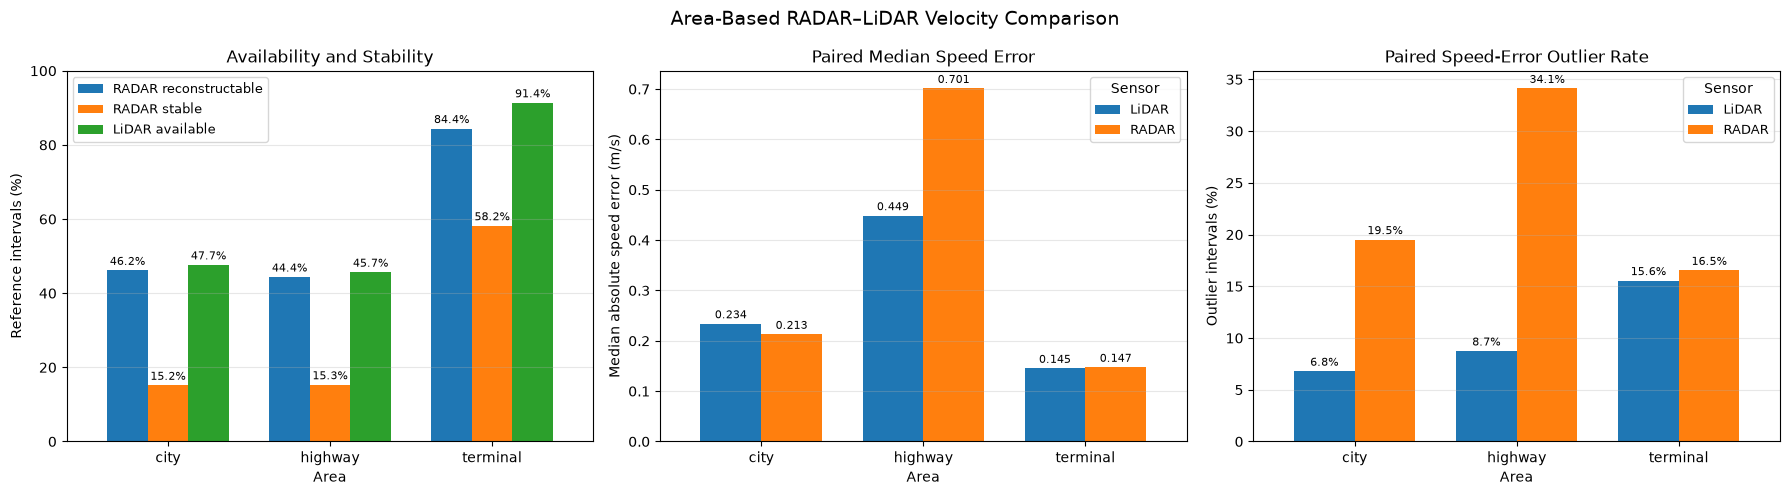

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Availability
availability_df = (
    area_summary
    .set_index("area")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
)

availability_df.plot(kind="bar", ax=axes[0], width=0.75)

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Area")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


# Figure 2: Paired median speed error
paired_speed_df = area_error_paired.pivot(
    index="area",
    columns="sensor",
    values="speed_err_median",
)

paired_speed_df.plot(kind="bar", ax=axes[1], width=0.75)

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].legend(title="Sensor", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)


# Figure 3: Paired outlier rate
paired_outlier_df = area_error_paired.pivot(
    index="area",
    columns="sensor",
    values="speed_err_outlier_pct",
)

paired_outlier_df.plot(kind="bar", ax=axes[2], width=0.75)

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Area")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].legend(title="Sensor", fontsize=9)
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Area-Based RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Weather

In [22]:
weather_lookup = condition_df[
    ["annotation_token", "scene_token", "weather"]
].rename(columns={
    "annotation_token": "start_annotation_token"
})

weather_df = comparison_df.merge(
    weather_lookup,
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

if weather_df["weather"].isna().any():
    raise ValueError(
        "Some velocity intervals could not be matched to a weather condition."
    )

weather_df = add_velocity_analysis_columns(weather_df)

print("Weather conditions:", weather_df["weather"].unique())
print("Intervals:", len(weather_df))

Weather conditions: <ArrowStringArray>
['clear', 'overcast', 'rain', 'snow']
Length: 4, dtype: str
Intervals: 15743


In [23]:
weather_summary = availability_summary(weather_df, "weather")
weather_summary

,weather,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,clear,4,296,6343,3379,1448,3524,1380,53.271323,22.828315,42.852915,55.557307,21.756267
1,overcast,3,265,4902,1978,679,1993,662,40.350877,13.851489,34.327604,40.656875,13.504692
2,rain,2,127,2945,1352,553,1508,541,45.908319,18.777589,40.902367,51.205433,18.370119
3,snow,1,62,1553,997,336,982,316,64.198326,21.635544,33.701103,63.232453,20.347714


In [24]:
weather_error_all = error_summary(weather_df, "weather", both_sensors_only=False)
weather_error_all

,weather,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,clear,RADAR,4,158,1448,0.314200,1.112768,23.960136,5.337778,304,20.994475,490,11.858528,128.034873
1,clear,LiDAR,4,217,3524,0.229226,0.469810,0.787401,1.175956,377,10.698070,1269,0.700852,3.419409
2,overcast,RADAR,3,117,679,0.527122,12.617157,48.418465,50.073871,239,35.198822,555,5.548692,147.540180
3,overcast,LiDAR,3,161,1993,0.280341,0.505816,0.796448,1.362488,202,10.135474,1466,0.372907,1.424392
4,rain,RADAR,2,55,553,0.136197,0.369465,28.697187,1.317017,93,16.817360,313,2.179399,8.965725
5,rain,LiDAR,2,81,1508,0.165733,0.366109,1.533570,1.252786,218,14.456233,1191,0.854099,3.047264
6,snow,RADAR,1,32,336,0.195984,0.408651,6.521586,5.076832,62,18.452381,117,6.890094,44.024069
7,snow,LiDAR,1,55,982,0.188632,0.405535,0.676176,0.886843,91,9.266802,318,1.736029,6.652337


In [25]:
weather_error_paired = error_summary(weather_df, "weather", both_sensors_only=True)
weather_error_paired

,weather,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,clear,RADAR,4,152,1380,0.298045,1.048052,21.142186,5.168794,287,20.797101,462,11.498384,119.351778
1,clear,LiDAR,4,152,1380,0.276641,0.540711,0.964979,1.277667,132,9.565217,462,0.791999,2.782483
2,overcast,RADAR,3,113,662,0.514813,12.068685,41.098392,46.102364,228,34.441088,540,5.019692,147.682658
3,overcast,LiDAR,3,113,662,0.420319,0.778028,0.967761,1.844495,60,9.063444,540,0.396013,1.328611
4,rain,RADAR,2,54,541,0.129888,0.351653,24.866899,1.207162,86,15.896488,301,2.176027,7.963183
5,rain,LiDAR,2,54,541,0.130415,0.339067,1.636640,1.297346,90,16.635860,301,0.566321,2.029975
6,snow,RADAR,1,28,316,0.187467,0.335565,5.909665,2.803443,50,15.822785,109,6.104828,35.797894
7,snow,LiDAR,1,28,316,0.166941,0.469376,0.884443,1.017779,37,11.708861,109,1.581699,4.597688


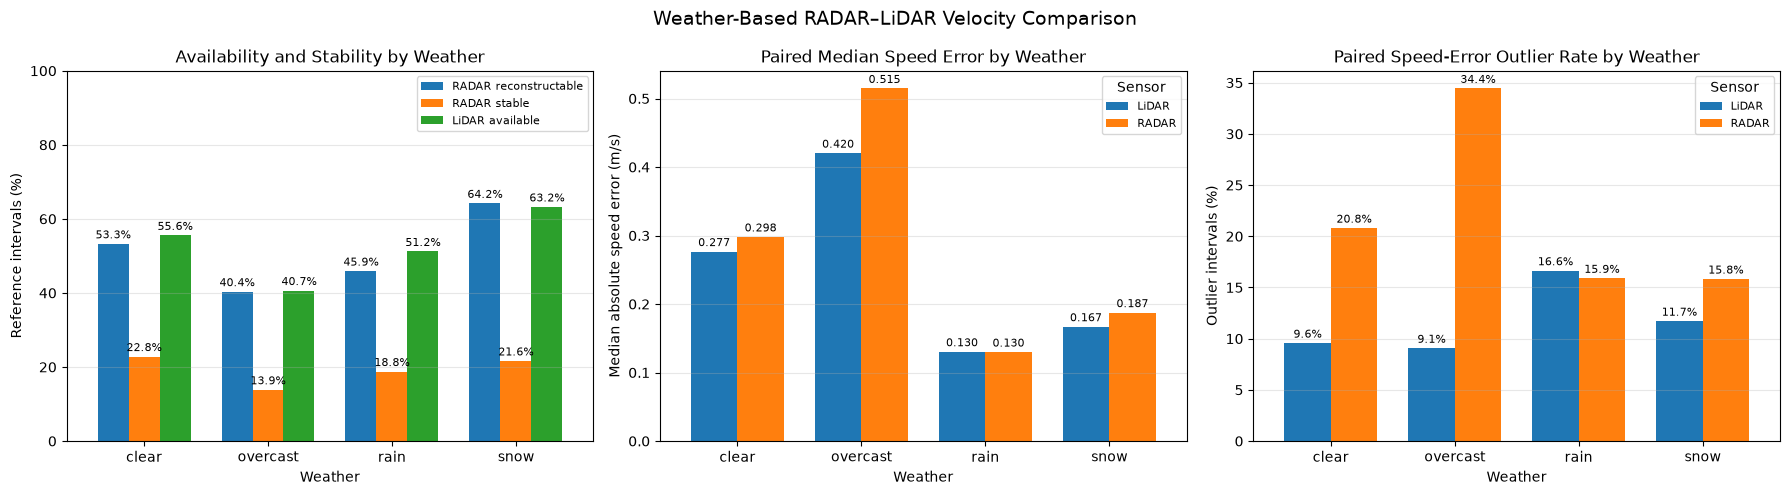

In [26]:
weather_order = weather_summary["weather"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Availability and stability
availability_df = (
    weather_summary
    .set_index("weather")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
    .reindex(weather_order)
)

availability_df.plot(kind="bar", ax=axes[0], width=0.75)

axes[0].set_title("Availability and Stability by Weather")
axes[0].set_xlabel("Weather")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


# 2. Paired median speed error
speed_df = (
    weather_error_paired
    .pivot(index="weather", columns="sensor", values="speed_err_median")
    .reindex(weather_order)
)

speed_df.plot(kind="bar", ax=axes[1], width=0.75)

axes[1].set_title("Paired Median Speed Error by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].legend(title="Sensor", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)


# 3. Paired speed-error outlier rate
outlier_df = (
    weather_error_paired
    .pivot(index="weather", columns="sensor", values="speed_err_outlier_pct")
    .reindex(weather_order)
)

outlier_df.plot(kind="bar", ax=axes[2], width=0.75)

axes[2].set_title("Paired Speed-Error Outlier Rate by Weather")
axes[2].set_xlabel("Weather")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].legend(title="Sensor", fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Weather-Based RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Visibility

In [39]:
condition_lookup = condition_df.set_index("annotation_token")
visibility_df = comparison_df.copy()

visibility_df["scene_token"] = (visibility_df["start_annotation_token"].map(condition_lookup["scene_token"]))
visibility_df["start_visibility"] = (visibility_df["start_annotation_token"].map(condition_lookup["visibility"]))
visibility_df["end_visibility"] = (visibility_df["end_annotation_token"].map(condition_lookup["visibility"]))

assert visibility_df[["scene_token", "start_visibility", "end_visibility"]].notna().all().all()

visibility_df["visibility"] = visibility_df[["start_visibility", "end_visibility"]].min(axis=1)

visibility_df = add_velocity_analysis_columns(visibility_df)

In [40]:
visibility_summary = availability_summary(visibility_df, "visibility")
visibility_summary

,visibility,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,1,10,547,5706,1288,309,1080,267,22.572730,5.415352,23.990683,18.927445,4.679285
1,2,10,313,1702,761,171,771,155,44.712103,10.047004,22.470434,45.299647,9.106933
2,3,10,291,1377,753,265,821,256,54.684096,19.244735,35.192563,59.622367,18.591140
3,4,10,448,6958,4904,2271,5335,2221,70.480023,32.638689,46.309135,76.674332,31.920092


In [41]:
visibility_error_all = error_summary(visibility_df, "visibility", both_sensors_only=False)
visibility_error_all

,visibility,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,1,RADAR,10,79,309,0.224889,0.991140,46.341113,14.881635,75,24.271845,115,4.549164,119.326846
1,1,LiDAR,10,191,1080,0.244816,0.607703,1.599410,1.604163,149,13.796296,514,0.730233,3.458865
2,2,RADAR,10,71,171,0.525175,4.890950,29.661746,25.162484,50,29.239766,80,9.095479,155.733963
3,2,LiDAR,10,195,771,0.280234,0.636266,1.243544,1.696936,98,12.710765,384,0.818198,4.962671
4,3,RADAR,10,101,265,0.355444,2.342772,41.891206,26.083755,69,26.037736,137,7.375584,138.932659
5,3,LiDAR,10,206,821,0.293768,0.621485,0.931114,1.512241,79,9.622412,412,0.729362,3.300321
6,4,RADAR,10,296,2271,0.268996,0.970928,27.423330,8.021737,484,21.312197,1143,4.569304,128.573450
7,4,LiDAR,10,394,5335,0.205779,0.401624,0.710464,1.006529,545,10.215558,2934,0.574601,2.606699


In [42]:
visibility_error_paired = error_summary(visibility_df, "visibility", both_sensors_only=True)
visibility_error_paired

,visibility,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,1,RADAR,10,62,267,0.184797,0.598069,28.368379,7.167876,56,20.973783,91,4.315896,105.719939
1,1,LiDAR,10,62,267,0.208119,0.495898,1.730747,1.631834,38,14.232210,91,0.635588,2.078747
2,2,RADAR,10,63,155,0.482970,4.040844,29.840451,24.097913,45,29.032258,71,6.637962,169.286851
3,2,LiDAR,10,63,155,0.557743,1.112813,2.042823,3.118539,17,10.967742,71,0.483480,2.219111
4,3,RADAR,10,96,256,0.350858,2.382816,35.867692,25.216592,67,26.171875,132,7.334982,138.937553
5,3,LiDAR,10,96,256,0.330704,0.860523,1.089211,1.697757,20,7.812500,132,0.574980,2.316250
6,4,RADAR,10,291,2221,0.264308,0.922650,25.741020,8.002990,468,21.071589,1118,4.374754,124.892278
7,4,LiDAR,10,291,2221,0.254236,0.514560,0.898920,1.273681,225,10.130572,1118,0.564967,2.399870


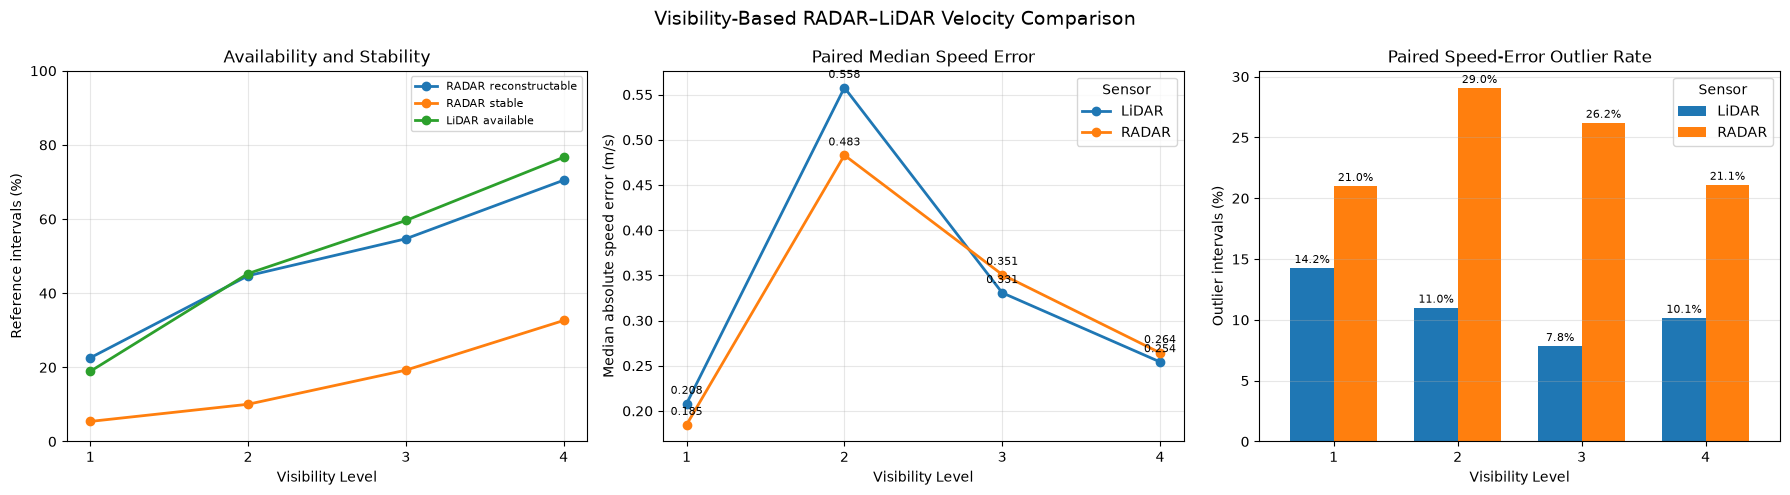

In [43]:
visibility_order = sorted(visibility_summary["visibility"].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# 1. Availability and stability trend
availability_df = (
    visibility_summary
    .set_index("visibility")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
    .reindex(visibility_order)
)

availability_df.plot(kind="line", marker="o", linewidth=2, ax=axes[0])

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Visibility Level")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_xticks(visibility_order)
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=8)
axes[0].grid(alpha=0.3)


# 2. Paired median speed error trend
speed_df = (
    visibility_error_paired
    .pivot(
        index="visibility",
        columns="sensor",
        values="speed_err_median",
    )
    .reindex(visibility_order)
)

speed_df.plot(kind="line", marker="o", linewidth=2, ax=axes[1])

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Visibility Level")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].set_xticks(visibility_order)
axes[1].legend(title="Sensor")
axes[1].grid(alpha=0.3)

for line in axes[1].lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        axes[1].annotate(
            f"{y:.3f}",
            (x, y),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )


# 3. Paired outlier rate
outlier_df = (
    visibility_error_paired
    .pivot(
        index="visibility",
        columns="sensor",
        values="speed_err_outlier_pct",
    )
    .reindex(visibility_order)
)

outlier_df.plot(kind="bar", width=0.7, ax=axes[2])

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Visibility Level")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].legend(title="Sensor")
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Visibility-Based RADAR–LiDAR Velocity Comparison", fontsize=14)

plt.tight_layout()
plt.show()

## 7. Object Type

All available vehicle categories were retained in the analysis. Categories with limited scene, instance, or paired-interval coverage are reported but interpreted cautiously because their estimates may not generalise beyond the small observed sample.

In [44]:
condition_lookup = condition_df.set_index("annotation_token")
object_type_df = comparison_df.copy()

object_type_df["scene_token"] = (object_type_df["start_annotation_token"].map(condition_lookup["scene_token"]))
object_type_df["object_type"] = (object_type_df["start_annotation_token"].map(condition_lookup["object_type"]))

assert object_type_df[["scene_token", "object_type"]].notna().all().all()

object_type_df = add_velocity_analysis_columns(object_type_df)

In [45]:
object_type_summary = (
    availability_summary(object_type_df, "object_type")
    .sort_values("intervals", ascending=False,)
    .reset_index(drop=True)
)

object_type_summary

,object_type,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,vehicle.car,10,554,11250,4431,1432,4744,1356,39.386667,12.728889,32.317761,42.168889,12.053333
1,vehicle.truck,10,96,2134,1584,565,1522,552,74.226804,26.476101,35.669192,71.321462,25.866917
2,vehicle.trailer,9,66,1402,1030,596,982,579,73.466476,42.510699,57.864078,70.042796,41.298146
3,vehicle.bus.rigid,4,12,367,255,125,295,115,69.482289,34.059946,49.019608,80.381471,31.335150
4,vehicle.train,1,5,195,195,183,195,183,100.000000,93.846154,93.846154,100.000000,93.846154
5,vehicle.construction,3,4,128,80,35,79,35,62.500000,27.34375,43.75,61.718750,27.343750
6,vehicle.bicycle,3,9,124,55,24,86,23,44.354839,19.354839,43.636364,69.354839,18.548387
7,vehicle.motorcycle,2,2,78,23,8,46,8,29.487179,10.25641,34.782609,58.974359,10.256410
8,vehicle.other,2,2,65,53,48,58,48,81.538462,73.846154,90.566038,89.230769,73.846154


In [46]:
object_type_error_all = error_summary(object_type_df, "object_type", both_sensors_only=False)
object_type_error_all

,object_type,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,vehicle.bicycle,RADAR,3,5,24,0.097091,0.126308,0.225948,0.458961,3,12.500000,16,3.283999,16.995932
1,vehicle.bicycle,LiDAR,3,7,86,0.108120,0.135783,0.132537,0.282399,3,3.488372,61,0.857453,3.178426
2,vehicle.bus.rigid,RADAR,4,9,125,0.233998,0.691490,7.678619,5.848780,31,24.800000,8,1.131561,49.355364
3,vehicle.bus.rigid,LiDAR,4,11,295,0.186551,0.450312,2.071935,1.522777,45,15.254237,56,0.319026,1.492501
4,vehicle.car,RADAR,10,226,1432,0.321692,1.238603,36.514246,10.851268,316,22.067039,797,5.315080,114.731070
5,vehicle.car,LiDAR,10,344,4744,0.216248,0.409882,0.578799,0.999984,438,9.232715,2502,0.673089,3.204158
6,vehicle.construction,RADAR,3,2,35,0.221885,0.220067,0.150044,0.442393,0,0.000000,26,1.953841,3.386939
7,vehicle.construction,LiDAR,3,3,79,0.125405,0.179813,0.354019,0.510605,8,10.126582,39,0.964110,1.805387
8,vehicle.motorcycle,RADAR,2,2,8,0.260917,0.319407,0.284772,0.706483,0,0.000000,7,0.473189,1.024825
9,vehicle.motorcycle,LiDAR,2,2,46,0.135410,0.189269,0.442487,0.544637,4,8.695652,28,0.096791,0.237825


In [47]:
object_type_error_paired = error_summary(object_type_df, "object_type", both_sensors_only=True,)
object_type_error_paired

,object_type,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,vehicle.bicycle,RADAR,3,5,23,0.099487,0.128265,0.229970,0.476875,3,13.043478,16,3.283999,16.995932
1,vehicle.bicycle,LiDAR,3,5,23,0.070010,0.081484,0.062228,0.180479,0,0.000000,16,0.546700,1.405559
2,vehicle.bus.rigid,RADAR,2,8,115,0.224889,0.687154,6.441179,4.640466,27,23.478261,8,1.131561,49.355364
3,vehicle.bus.rigid,LiDAR,2,8,115,0.171677,0.544247,2.539874,2.529142,24,20.869565,8,0.962517,13.709002
4,vehicle.car,RADAR,9,214,1356,0.300850,1.039645,28.162741,8.818988,285,21.017699,745,4.674866,112.134351
5,vehicle.car,LiDAR,9,214,1356,0.282764,0.524999,0.630135,1.186953,103,7.595870,745,0.644623,2.554448
6,vehicle.construction,RADAR,2,2,35,0.221885,0.220067,0.150044,0.442393,0,0.000000,26,1.953841,3.386939
7,vehicle.construction,LiDAR,2,2,35,0.130415,0.149201,0.486834,0.540118,5,14.285714,26,0.867714,1.724659
8,vehicle.motorcycle,RADAR,2,2,8,0.260917,0.319407,0.284772,0.706483,0,0.000000,7,0.473189,1.024825
9,vehicle.motorcycle,LiDAR,2,2,8,0.294500,0.721962,0.857356,1.648183,1,12.500000,7,0.060869,0.201950


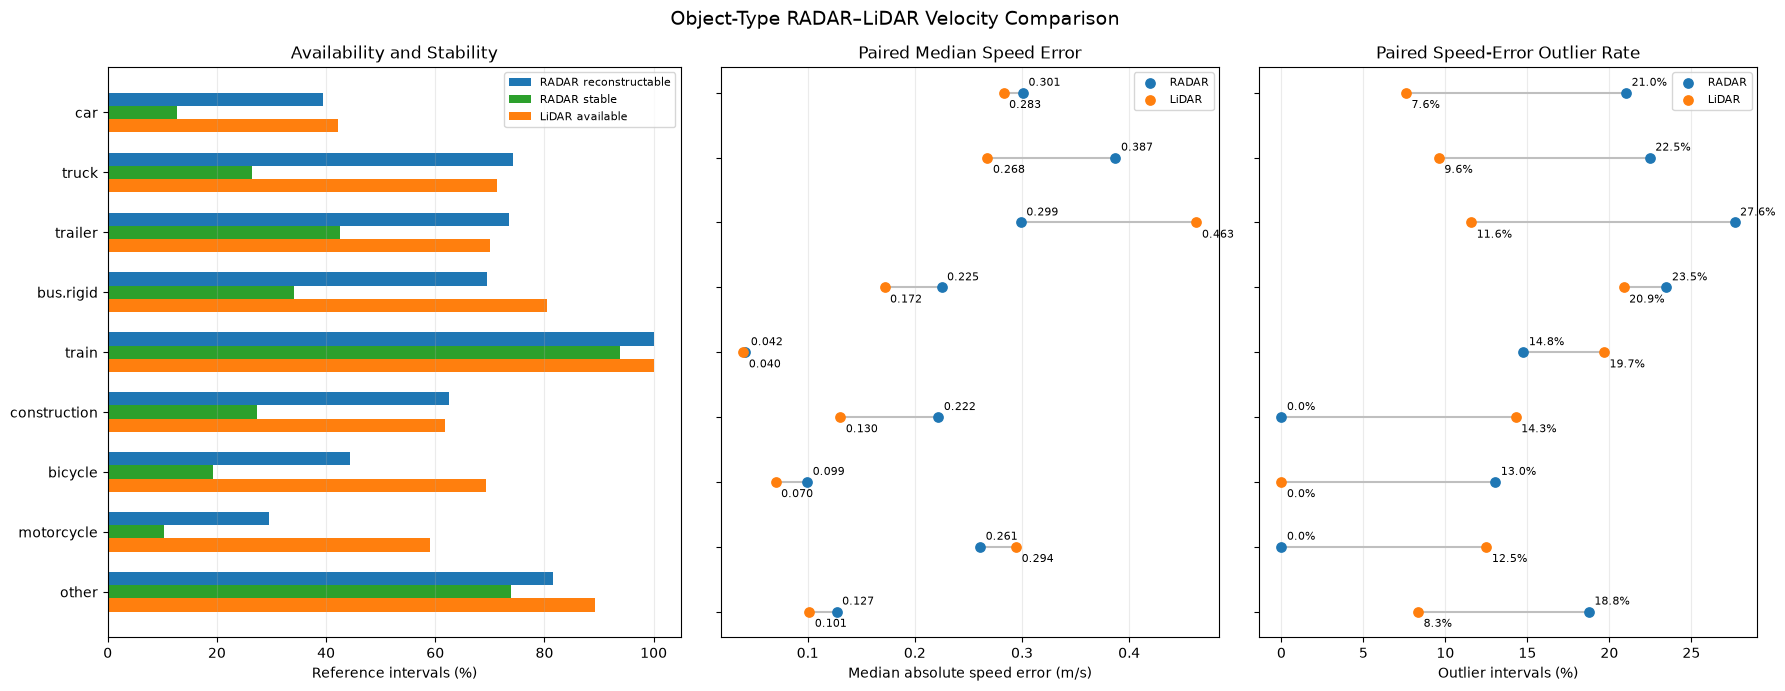

In [48]:
# Order by number of reference intervals
object_order = (object_type_summary.sort_values("intervals")["object_type"].tolist())

labels = [x.replace("vehicle.", "") for x in object_order]
y = np.arange(len(object_order))

radar_color = "C0"
lidar_color = "C1"
stable_color = "C2"

fig, axes = plt.subplots(1, 3, figsize=(18, 7), gridspec_kw={"width_ratios": [1.15, 1, 1]},)

# 1. Availability and stability
summary = (object_type_summary.set_index("object_type").reindex(object_order))

h = 0.22
axes[0].barh(
    y + h,
    summary["radar_reconstructable_pct"],
    height=h,
    label="RADAR reconstructable",
    color=radar_color,
)
axes[0].barh(
    y,
    summary["radar_stable_pct"],
    height=h,
    label="RADAR stable",
    color=stable_color,
)
axes[0].barh(
    y - h,
    summary["lidar_pct"],
    height=h,
    label="LiDAR available",
    color=lidar_color,
)

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Reference intervals (%)")
axes[0].set_yticks(y)
axes[0].set_yticklabels(labels)
axes[0].set_xlim(0, 105)
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=8)

# 2. Paired median speed error
speed = (
    object_type_error_paired
    .pivot(index="object_type", columns="sensor", values="speed_err_median")
    .reindex(object_order)
)

for i, row in enumerate(speed.itertuples()):
    axes[1].plot([row.RADAR, row.LiDAR], [i, i], color="0.75", linewidth=1.5)

axes[1].scatter(speed["RADAR"], y, label="RADAR", color=radar_color, s=45, zorder=3)
axes[1].scatter(speed["LiDAR"], y, label="LiDAR", color=lidar_color, s=45, zorder=3)

for i in range(len(speed)):
    axes[1].annotate(
        f'{speed.iloc[i]["RADAR"]:.3f}',
        (speed.iloc[i]["RADAR"], i),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )

    axes[1].annotate(
        f'{speed.iloc[i]["LiDAR"]:.3f}',
        (speed.iloc[i]["LiDAR"], i),
        xytext=(4, -11),
        textcoords="offset points",
        fontsize=8,
    )

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Median absolute speed error (m/s)")
axes[1].set_yticks(y)
axes[1].set_yticklabels([])
axes[1].grid(axis="x", alpha=0.25)
axes[1].legend(fontsize=8)

# 3. Paired outlier rate
outlier = (
    object_type_error_paired
    .pivot(index="object_type", columns="sensor", values="speed_err_outlier_pct")
    .reindex(object_order)
)

for i, row in enumerate(outlier.itertuples()):
    axes[2].plot([row.RADAR, row.LiDAR], [i, i], color="0.75", linewidth=1.5)

axes[2].scatter(outlier["RADAR"], y, label="RADAR", color=radar_color, s=45, zorder=3)
axes[2].scatter(outlier["LiDAR"], y, label="LiDAR", color=lidar_color, s=45, zorder=3)

for i in range(len(outlier)):
    axes[2].annotate(
        f'{outlier.iloc[i]["RADAR"]:.1f}%',
        (outlier.iloc[i]["RADAR"], i),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )

    axes[2].annotate(
        f'{outlier.iloc[i]["LiDAR"]:.1f}%',
        (outlier.iloc[i]["LiDAR"], i),
        xytext=(4, -11),
        textcoords="offset points",
        fontsize=8,
    )

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Outlier intervals (%)")
axes[2].set_yticks(y)
axes[2].set_yticklabels([])
axes[2].grid(axis="x", alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Object-Type RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Distance

In [49]:
condition_lookup = condition_df.set_index("annotation_token")
distance_df = comparison_df.copy()
distance_df["scene_token"] = (distance_df["start_annotation_token"].map(condition_lookup["scene_token"]))
distance_df["start_distance_3d"] = (distance_df["start_annotation_token"].map(condition_lookup["distance_3d"]))
distance_df["end_distance_3d"] = (distance_df["end_annotation_token"].map(condition_lookup["distance_3d"]))

assert distance_df[["scene_token", "start_distance_3d", "end_distance_3d"]].notna().all().all()

distance_df["distance_3d"] = (distance_df["start_distance_3d"] + distance_df["end_distance_3d"]) / 2
distance_df["distance"] = create_distance_bands(distance_df["distance_3d"])
distance_df = add_velocity_analysis_columns(distance_df)

In [50]:
distance_summary = availability_summary(distance_df, "distance")
distance_summary

,distance,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,"[0.0, 25.0)",10,217,2128,1905,1605,2069,1576,89.520677,75.422932,84.251969,97.227444,74.060150
1,"[25.0, 50.0)",10,391,3573,2633,1125,3133,1087,73.691576,31.486146,42.726927,87.685418,30.422614
2,"[50.0, 75.0)",10,464,3072,1494,252,1688,211,48.632812,8.203125,16.86747,54.947917,6.868490
3,"[75.0, 100.0)",10,447,2398,843,27,705,22,35.154295,1.125938,3.202847,29.399500,0.917431
4,"[100.0, 125.0)",9,373,1764,429,1,222,0,24.319728,0.056689,0.2331,12.585034,0.000000
5,"[125.0, 150.0)",9,343,1280,262,6,125,3,20.468750,0.46875,2.290076,9.765625,0.234375
6,"[150.0, 175.0)",9,262,745,106,0,46,0,14.228188,0.0,0.0,6.174497,0.000000
7,"[175.0, 200.0)",8,205,559,34,0,18,0,6.082290,0.0,0.0,3.220036,0.000000
8,"[200.0, 225.0)",8,97,223,0,0,1,0,0.000000,0.0,NaN,0.448430,0.000000
9,"[225.0, 250.0)",1,1,1,0,0,0,0,0.000000,0.0,NaN,0.000000,0.000000


In [51]:
distance_error_all = error_summary(distance_df, "distance", both_sensors_only=False)
distance_error_all

,distance,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,"[0.0, 25.0)",RADAR,10,203,1605,0.184960,0.444993,8.370474,1.745056,241,15.015576,662,2.958348,111.286284
1,"[0.0, 25.0)",LiDAR,10,215,2069,0.201189,0.466546,0.812025,1.169353,237,11.454809,901,0.525577,2.499830
2,"[25.0, 50.0)",RADAR,10,270,1125,0.355444,2.583660,32.375314,17.023946,313,27.822222,582,17.760461,139.062384
3,"[25.0, 50.0)",LiDAR,10,375,3133,0.192769,0.388032,1.021716,1.062239,356,11.362911,1511,0.688975,2.764842
4,"[50.0, 75.0)",RADAR,10,144,252,2.062772,18.410954,61.674119,109.699322,82,32.539683,198,12.615542,116.986553
5,"[50.0, 75.0)",LiDAR,10,364,1688,0.275575,0.521437,0.927963,1.318490,175,10.367299,1006,0.708507,3.819864
6,"[75.0, 100.0)",RADAR,10,26,27,76.095570,160.214963,107.349562,254.269537,0,0.000000,26,66.458016,123.670929
7,"[75.0, 100.0)",LiDAR,10,196,705,0.249159,0.499074,1.088664,1.319340,72,10.212766,477,0.570363,2.833897
8,"[100.0, 125.0)",RADAR,9,1,1,313.702333,0.000000,NaN,313.702333,0,0.000000,1,67.259989,67.259989
9,"[100.0, 125.0)",LiDAR,9,92,222,0.369979,0.734894,1.052345,1.858367,20,9.009009,171,0.537875,2.055062


In [52]:
distance_error_paired = error_summary(distance_df, "distance", both_sensors_only=True)
distance_error_paired

,distance,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,"[0.0, 25.0)",RADAR,10,202,1576,0.181436,0.423871,8.431588,1.640482,232,14.720812,655,2.933901,96.848604
1,"[0.0, 25.0)",LiDAR,10,202,1576,0.240499,0.527263,0.895536,1.277341,164,10.406091,655,0.560120,2.603276
2,"[25.0, 50.0)",RADAR,10,261,1087,0.344992,2.291246,26.949455,15.857450,295,27.138914,560,16.761119,140.886490
3,"[25.0, 50.0)",LiDAR,10,261,1087,0.254236,0.542639,1.188303,1.437395,129,11.867525,560,0.646473,2.352515
4,"[50.0, 75.0)",RADAR,8,125,211,2.026282,19.238766,59.317489,110.142623,70,33.175355,173,11.348206,116.209520
5,"[50.0, 75.0)",LiDAR,8,125,211,0.536053,0.931847,1.812866,2.460543,21,9.952607,173,0.484674,1.811318
6,"[75.0, 100.0)",RADAR,3,21,22,82.840546,159.744462,99.010489,238.352263,0,0.000000,21,66.800472,127.341067
7,"[75.0, 100.0)",LiDAR,3,21,22,0.544523,0.764181,1.801765,1.485408,1,4.545455,21,0.320822,0.749959
8,"[125.0, 150.0)",RADAR,1,1,3,2.986788,2.687479,3.005028,6.999749,1,33.333333,3,3.507230,9.522711
9,"[125.0, 150.0)",LiDAR,1,1,3,0.095245,0.078260,0.084406,0.201664,1,33.333333,3,0.105621,0.488255


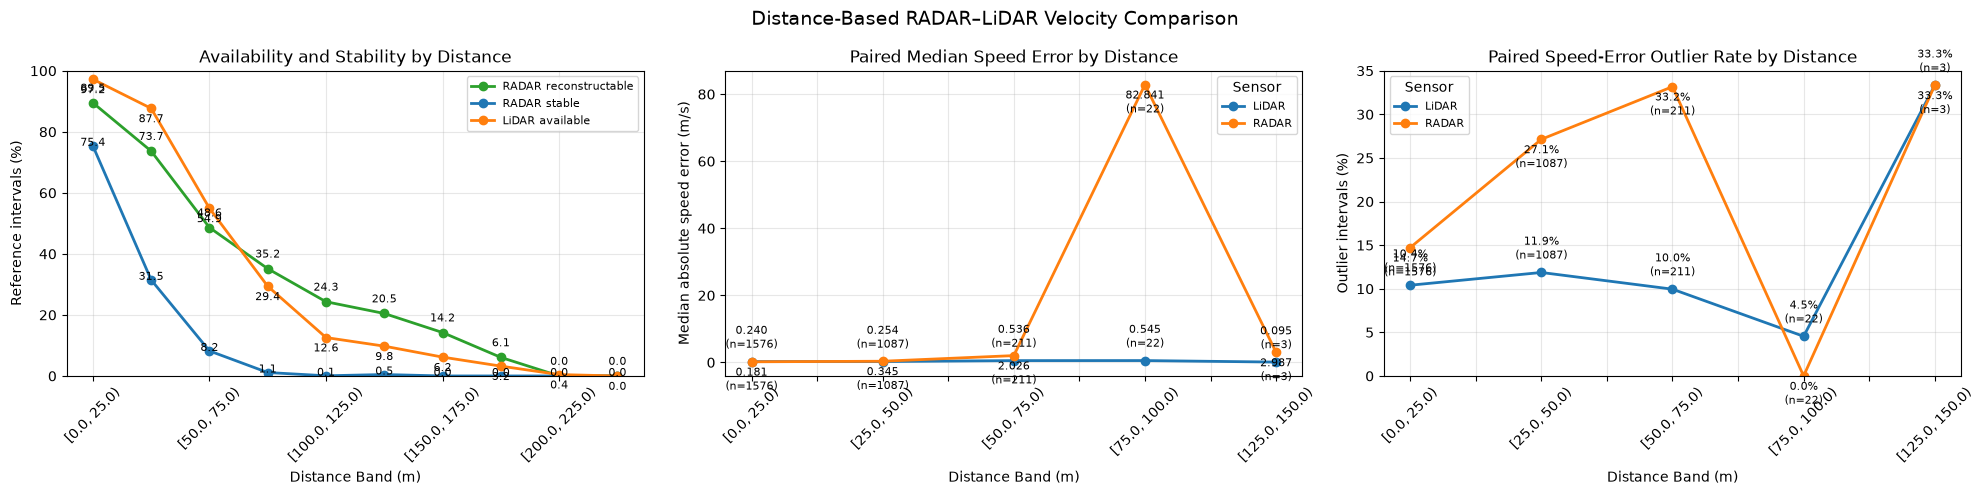

In [53]:
radar_color = "C0"
lidar_color = "C1"
reconstructable_color = "C2"

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Availability / Stability
availability_df = (
    distance_summary
    .copy()
    .set_index("distance")[
        [
            "radar_reconstructable_pct",
            "radar_stable_pct",
            "lidar_pct",
        ]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
)

availability_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[0],
    color=[reconstructable_color, radar_color, lidar_color],
)

axes[0].set_title("Availability and Stability by Distance")
axes[0].set_xlabel("Distance Band (m)")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="", fontsize=8)

for line_idx, line in enumerate(axes[0].lines):
    offset = 8 if line_idx == 0 else (0 if line_idx == 1 else -10)
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        axes[0].annotate(
            f"{y:.1f}",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

# 2) Paired Median Speed Error (only bins with paired_n > 0)
paired_bins = distance_summary.loc[distance_summary["paired_n"] > 0, "distance"].tolist()

speed_df = (
    distance_error_paired
    .pivot(index="distance", columns="sensor", values="speed_err_median")
    .reindex(paired_bins)
)

speed_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color=[radar_color, lidar_color],
)

axes[1].set_title("Paired Median Speed Error by Distance")
axes[1].set_xlabel("Distance Band (m)")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Sensor", fontsize=8)

paired_n_lookup = (
    distance_summary
    .set_index("distance")["paired_n"]
    .to_dict()
)

for line_idx, line in enumerate(axes[1].lines):
    offset = 10 if line_idx == 0 else -20
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        label = speed_df.index[x]
        n = paired_n_lookup[label]
        axes[1].annotate(
            f"{y:.3f}\n(n={n})",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

# 3) Paired Outlier Rate (only bins with paired_n > 0)
outlier_df = (
    distance_error_paired
    .pivot(
        index="distance",
        columns="sensor",
        values="speed_err_outlier_pct",
    )
    .reindex(paired_bins)
)

outlier_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[2],
    color=[radar_color, lidar_color],
)

axes[2].set_title("Paired Speed-Error Outlier Rate by Distance")
axes[2].set_xlabel("Distance Band (m)")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Sensor", fontsize=8)

for line_idx, line in enumerate(axes[2].lines):
    offset = 10 if line_idx == 0 else -20
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        label = outlier_df.index[x]
        n = paired_n_lookup[label]
        axes[2].annotate(
            f"{y:.1f}%\n(n={n})",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

plt.suptitle(
    "Distance-Based RADAR–LiDAR Velocity Comparison",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 9. Cross-Condition Interaction Analysis

Research Question:
How do multiple operating conditions jointly affect RADAR and LiDAR velocity performance?

In [54]:
cross_condition_df = build_cross_condition_df(comparison_df, condition_df)
paired_long_df = build_paired_long_df(cross_condition_df)
model_df = prepare_interaction_model_df(paired_long_df)
interaction_model = fit_sensor_condition_model(model_df, clustered=False)

print("Observations:", int(interaction_model.nobs))
print("R-squared:", round(interaction_model.rsquared, 3))
print("Adjusted R-squared:", round(interaction_model.rsquared_adj, 3))

Observations: 5798
R-squared: 0.381
Adjusted R-squared: 0.377


In [55]:
coef_table = pd.DataFrame({
    "coefficient": interaction_model.params,
    "std_error": interaction_model.bse,
    "p_value": interaction_model.pvalues,
    "ci_low": interaction_model.conf_int()[0],
    "ci_high": interaction_model.conf_int()[1],
})

display(coef_table)

,coefficient,std_error,p_value,ci_low,ci_high
Intercept,0.300637,0.034322,2.548212e-18,0.233353,0.367921
"C(sensor, Treatment(reference=""LiDAR""))[T.RADAR]",-0.450331,0.048539,2.397495e-20,-0.545486,-0.355177
"C(area, Treatment(reference=""city""))[T.highway]",0.225027,0.043936,3.126031e-07,0.138896,0.311158
"C(area, Treatment(reference=""city""))[T.terminal]",-0.061985,0.041974,1.397943e-01,-0.144269,0.020299
"C(weather, Treatment(reference=""clear""))[T.overcast]",-0.043112,0.045270,3.409646e-01,-0.131859,0.045634
"C(weather, Treatment(reference=""clear""))[T.rain]",-0.125624,0.050441,1.278444e-02,-0.224508,-0.026740
"C(weather, Treatment(reference=""clear""))[T.snow]",-0.084672,0.053106,1.109014e-01,-0.188781,0.019436
"C(visibility, Treatment(reference=4))[T.1]",0.134195,0.054544,1.391112e-02,0.027268,0.241122
"C(visibility, Treatment(reference=4))[T.2]",0.227801,0.057898,8.433256e-05,0.114300,0.341302
"C(visibility, Treatment(reference=4))[T.3]",0.068965,0.045523,1.298379e-01,-0.020277,0.158206


In [56]:
condition_interaction_model = fit_condition_interaction_model(model_df, clustered=False)

print("Observations:", int(condition_interaction_model.nobs))
print("Parameters:", len(condition_interaction_model.params))
print("R-squared:", round(condition_interaction_model.rsquared, 3))
print("Adjusted R-squared:", round(condition_interaction_model.rsquared_adj, 3))

Observations: 5798
Parameters: 137
R-squared: 0.422
Adjusted R-squared: 0.412


f:\CITS3200\Boeing-RADAR-Autonomous-\src\condition\cross_condition.py:128: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return model.fit()


In [ ]:
# 这个代码后面可以删掉，这是为了进行一个验证
# 如果Rank deficiency: 0，那model就没有问题，如果不是0，就根据数据再删掉某些无法估计的interaction
# X = condition_interaction_model.model.exog
# rank = np.linalg.matrix_rank(X)

# print("Design matrix columns:", X.shape[1])
# print("Design matrix rank:", rank)
# print("Rank deficiency:", X.shape[1] - rank)

Design matrix columns: 137
Design matrix rank: 101
Rank deficiency: 36


### Visualisation

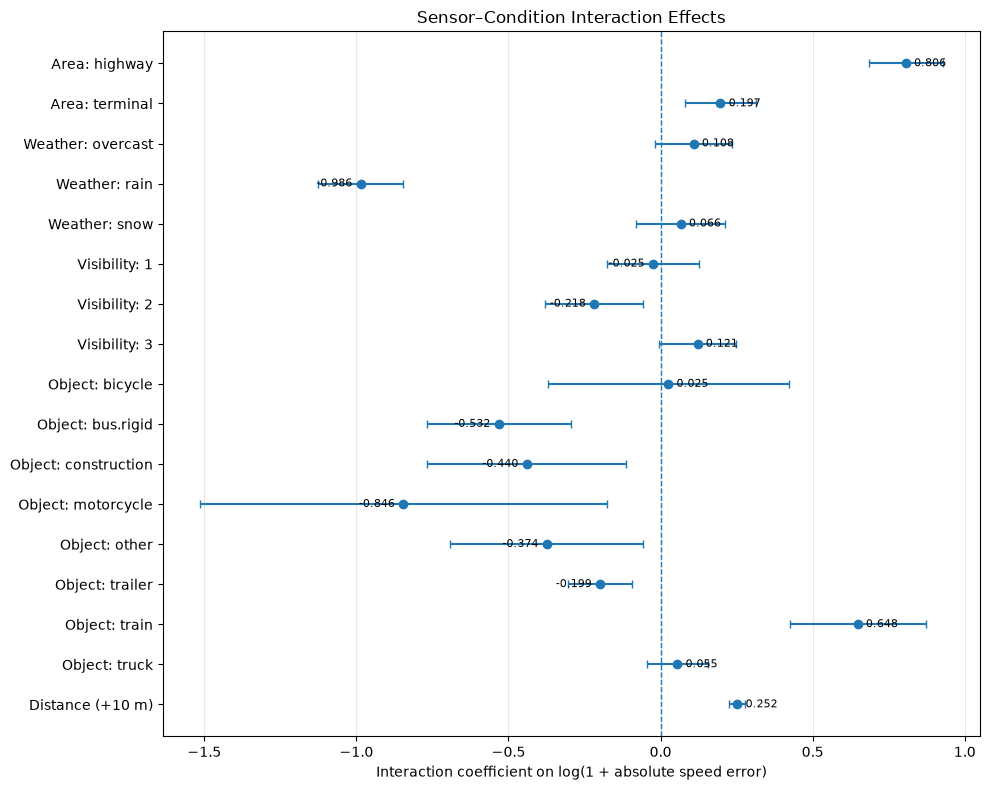

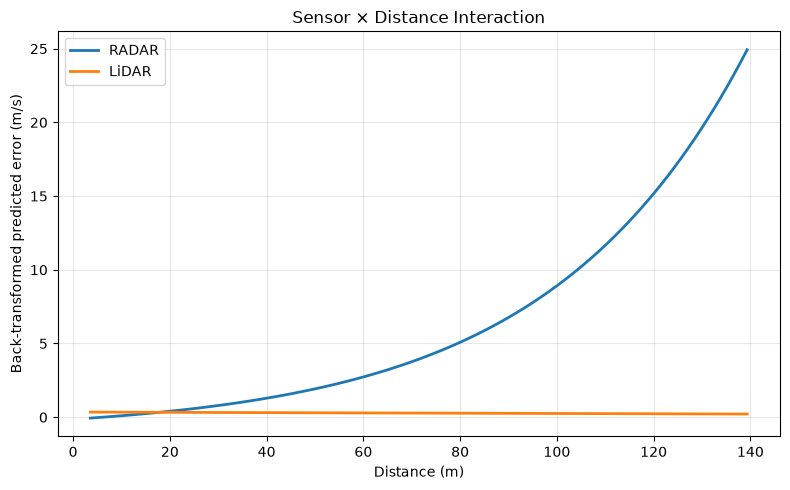

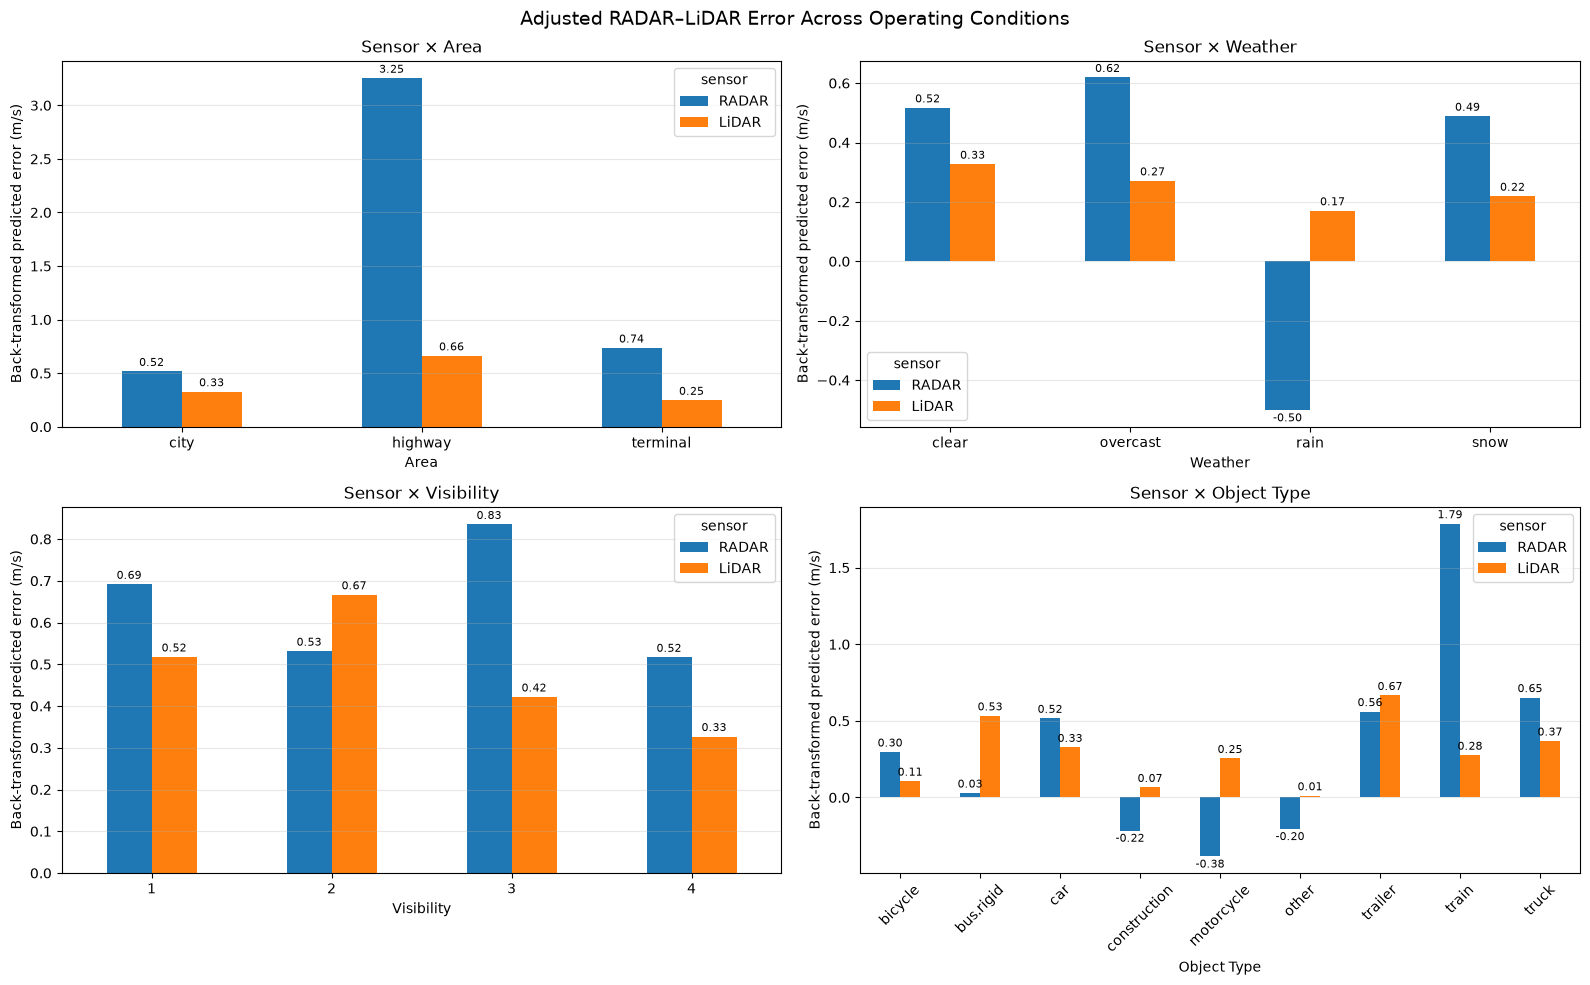

Condition–condition interaction plot skipped: the current model is rank-deficient.


In [58]:
plot_sensor_interaction_coefficients(interaction_model)
plot_sensor_distance_interaction(interaction_model, model_df)
plot_sensor_condition_grid(interaction_model, model_df)
plot_condition_interactions(condition_interaction_model)

## 10. RADAR–LiDAR Complementarity and Fusion

This section investigates whether combining RADAR and LiDAR can improve velocity
coverage and velocity accuracy.

Two aspects are considered:

1. **Sensor complementarity:** whether combining the availability of both sensors
   increases the number of reference intervals for which a velocity estimate is
   available.

2. **Velocity fusion:** whether a simple vector-average fusion of RADAR and LiDAR
   improves velocity accuracy when both sensors provide a valid estimate.

Each reference interval is classified as **Both**, **RADAR only**, **LiDAR only**
or **Neither** according to stable RADAR velocity availability and LiDAR velocity
availability.

Combined availability represents intervals for which at least one sensor
provides a valid velocity estimate.

For intervals where both sensors provide a valid velocity estimate, a simple
baseline fusion is constructed by averaging the RADAR and LiDAR horizontal
velocity vectors:

$$
v_{x,\mathrm{fused}} =
\frac{v_{x,\mathrm{RADAR}} + v_{x,\mathrm{LiDAR}}}{2},
\qquad
v_{y,\mathrm{fused}} =
\frac{v_{y,\mathrm{RADAR}} + v_{y,\mathrm{LiDAR}}}{2}
$$

No model training or optimisation is used. The purpose is to establish a simple,
reproducible fusion baseline before considering more complex weighting methods.

In [42]:
fusion_df = add_fusion_columns(cross_condition_df)
complementarity = complementarity_summary(fusion_df)
fusion_accuracy = fusion_accuracy_summary(fusion_df)

display(complementarity)
display(fusion_accuracy)

,metric,intervals,pct_reference
0,RADAR stable,3016,19.2
1,LiDAR available,8007,50.9
2,Both,2899,18.4
3,RADAR only,117,0.7
4,LiDAR only,5108,32.4
5,Neither,7619,48.4
6,Combined available,8124,51.6
7,Incremental vs RADAR,5108,32.4
8,Incremental vs LiDAR,117,0.7


,sensor,intervals,speed_err_median,speed_err_iqr,speed_err_p90,dir_err_median,dir_err_p90
0,RADAR,2899,0.266,1.022,9.558,4.563,130.242
1,LiDAR,2899,0.263,0.566,1.437,0.570,2.358
2,Fused,2899,0.241,0.813,7.207,2.448,69.958


In [43]:
fusion_by_area = fusion_condition_summary(fusion_df, "area")
fusion_by_weather = fusion_condition_summary(fusion_df, "weather")
fusion_by_visibility = fusion_condition_summary(fusion_df, "visibility")
fusion_by_object = fusion_condition_summary(fusion_df, "object_type")
fusion_by_distance = fusion_condition_summary(fusion_df, "distance")

In [ ]:
# display(fusion_by_area)
# display(fusion_by_weather)
# display(fusion_by_visibility)
# display(fusion_by_object)
# display(fusion_by_distance)

In [45]:
fusion_gain_area = fusion_gain_summary(fusion_by_area, "area")
fusion_gain_weather = fusion_gain_summary(fusion_by_weather, "weather")
fusion_gain_visibility = fusion_gain_summary(fusion_by_visibility, "visibility")
fusion_gain_object = fusion_gain_summary(fusion_by_object, "object_type")
fusion_gain_distance = fusion_gain_summary(fusion_by_distance, "distance")

In [46]:
# display(fusion_gain_area)
# display(fusion_gain_weather)
# display(fusion_gain_visibility)
# display(fusion_gain_object)
# display(fusion_gain_distance)

### Visualisation

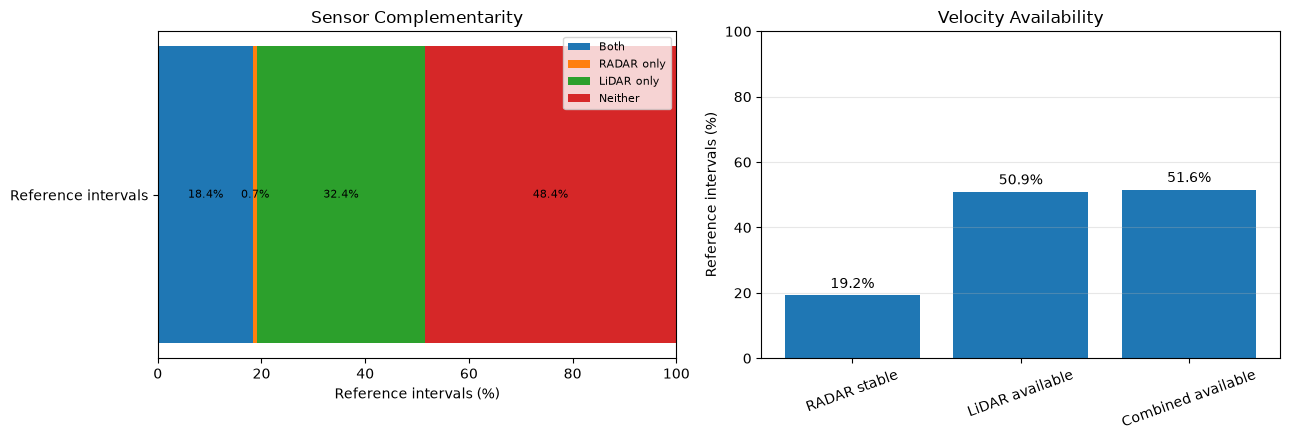

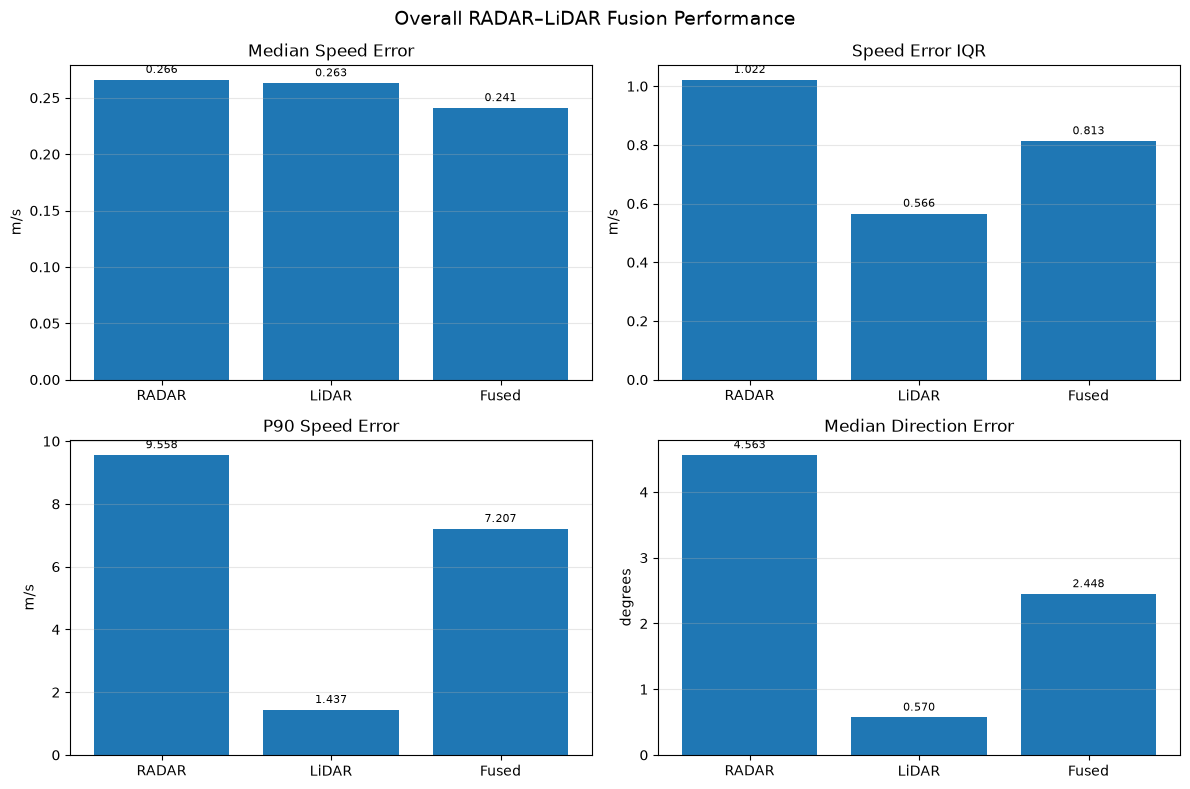

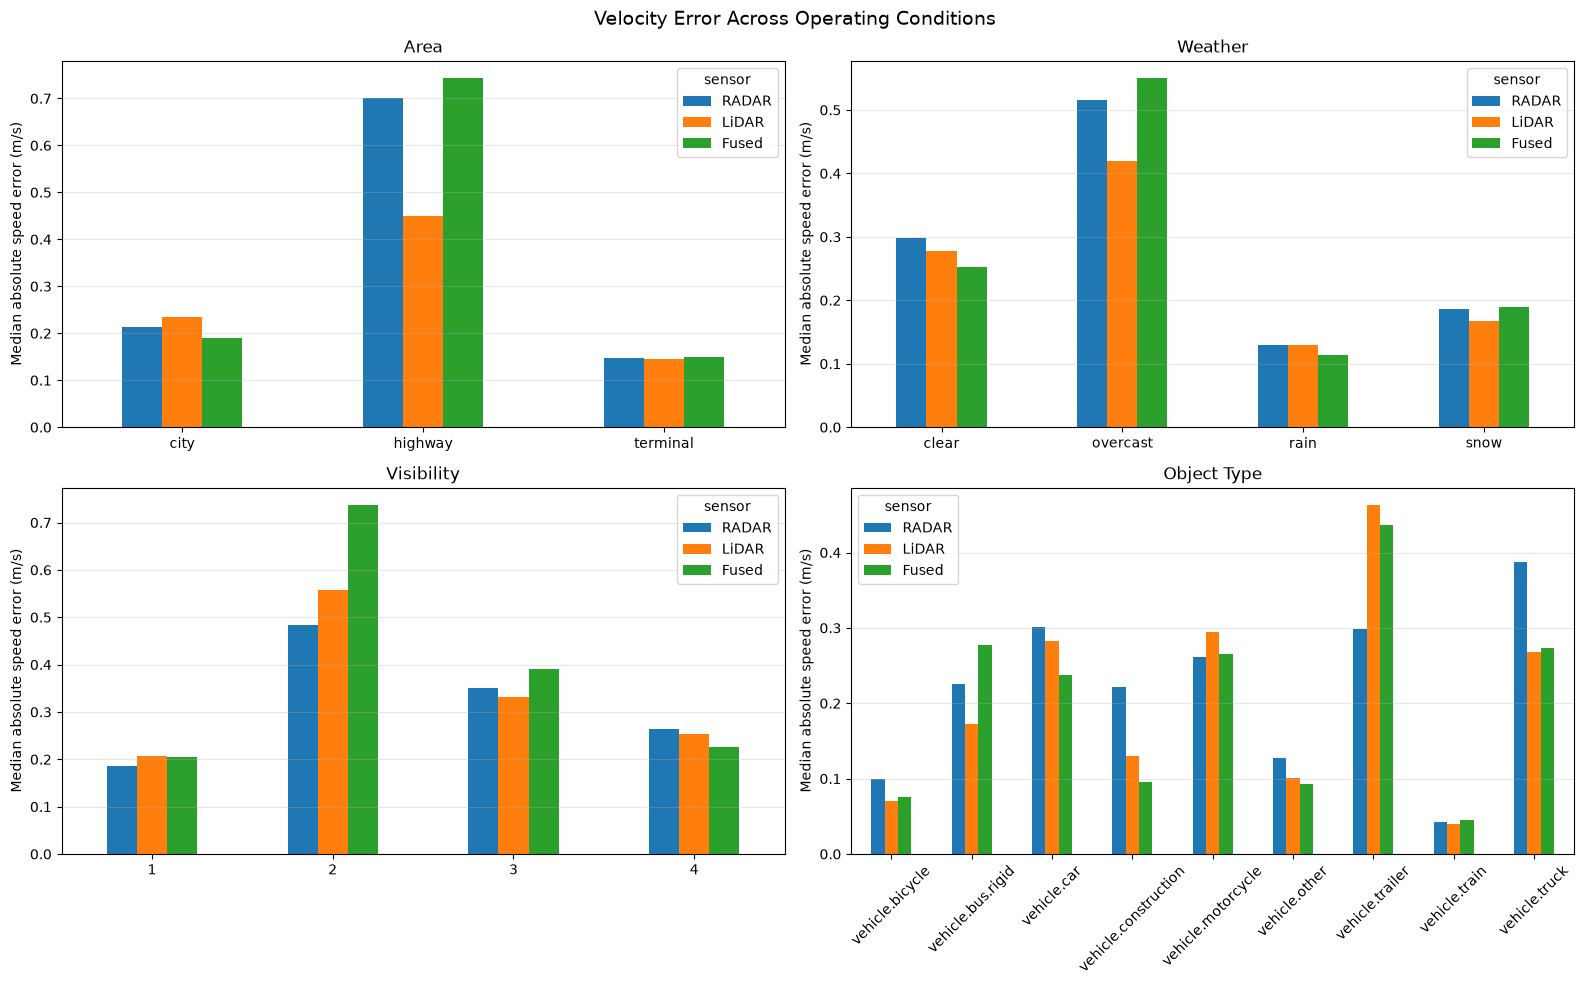

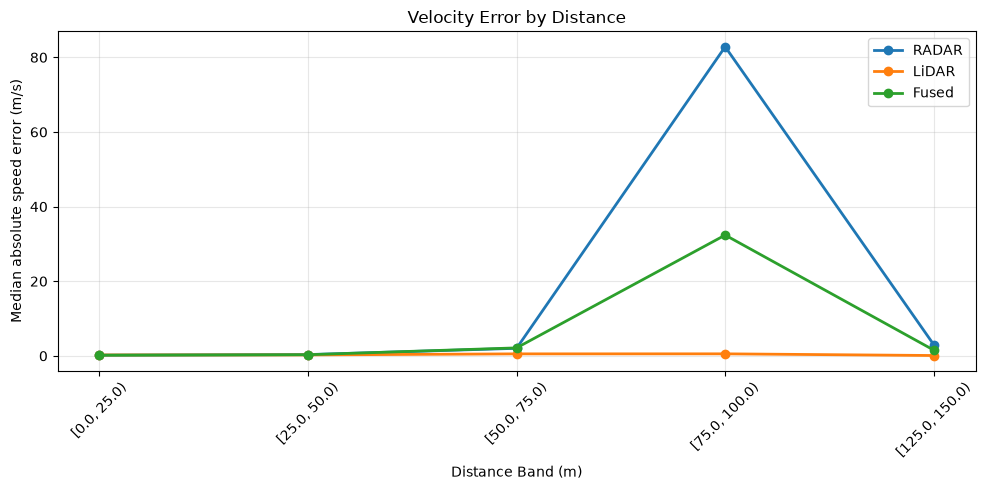

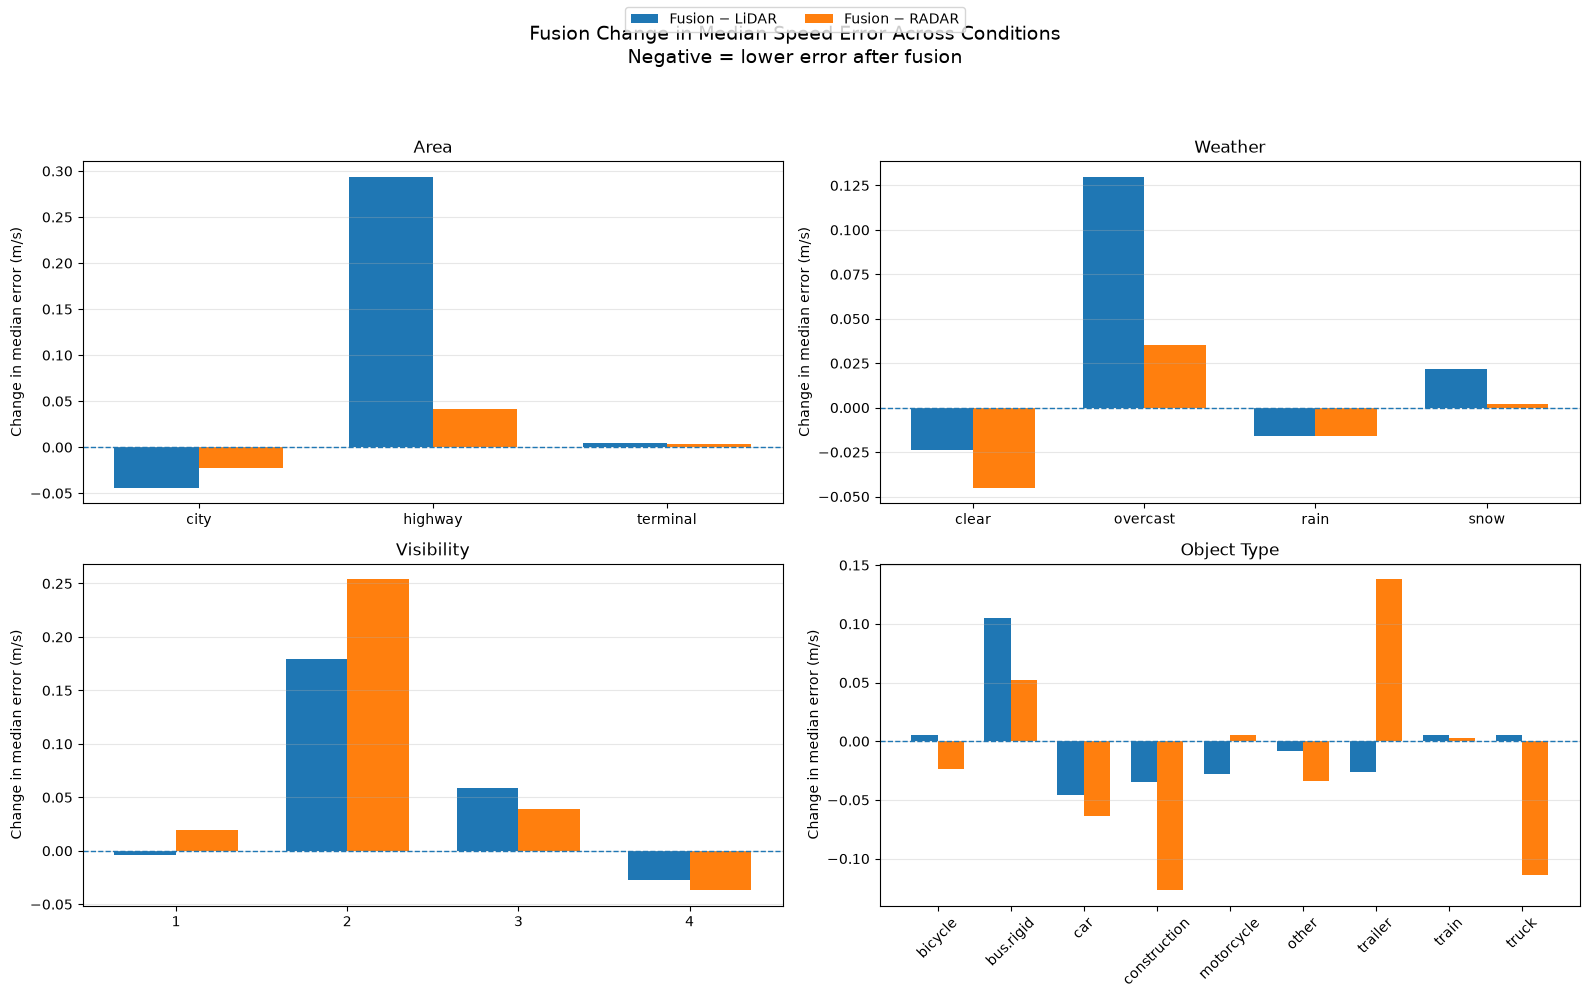

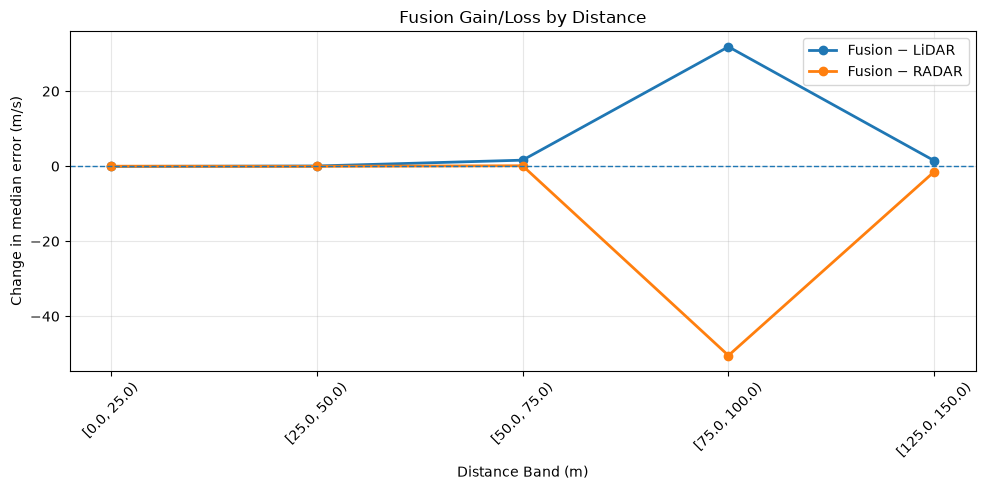

In [47]:
plot_fusion_complementarity(complementarity)
plot_overall_fusion_accuracy(fusion_accuracy)

plot_fusion_condition_grid(
    fusion_by_area,
    fusion_by_weather,
    fusion_by_visibility,
    fusion_by_object,
)

plot_fusion_distance(fusion_by_distance)

plot_fusion_gain_grid(
    fusion_gain_area,
    fusion_gain_weather,
    fusion_gain_visibility,
    fusion_gain_object,
)

plot_fusion_gain_distance(fusion_gain_distance)

## 11. Key Findings

## 12. Limitations

## 13. Conclusion